## Librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
sys.path.append(r"C:\Users\Usuario\ProjecteData\Equip_25\Scripts")
from utils import guardar_grafico

## Carga datos clean

In [2]:
df_operaciones = pd.read_csv('C:\\Users\\Usuario\\Desktop\\PROYECTO\\operaciones_09-03-2026.csv', parse_dates=['insert_date'])

In [3]:
total_anuncios = df_operaciones["apartment_id"].nunique()                      
apartamentos_disponibles = (                                                    
    df_operaciones["apartment_id"].count() - 
    (df_operaciones["has_availability"]==False).sum())                          
available_30 = (df_operaciones["availability_30"] > 0).sum()                            
ratio_oferta_disponible = round((available_30 / apartamentos_disponibles) * 100, 2)     
fully_booked_active = df_operaciones[
    (df_operaciones["fully_booked"]) & 
    (df_operaciones["has_availability"])
].shape[0]       

## Análisis / visualizaciones
Quina és la disponibilitat mitjana dels allotjaments
turístics en els diferents terminis (30, 60, 90 i 365 dies) a cada ciutat?

Para poder comparar los distintos horizontes temporales (30, 60, 90 y 365 días), primero se transformaron los valores de disponibilidad en ratios relativos, dividiendo el número de días disponibles entre el total de días de cada periodo. De esta forma se obtiene el porcentaje de disponibilidad. Posteriormente se calculó la media de estos ratios por ciudad, lo que permite realizar comparaciones más justas entre ciudades y horizontes temporales.

In [4]:
availability_cols = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365"
]

disponibilidad_ciudad_raw = (
    df_operaciones
    .groupby("city")[availability_cols]
    .mean()
    .round(0)
    .reset_index()
    .sort_values(by="availability_30", ascending=True)
)

disponibilidad_ciudad_raw

,city,availability_30,availability_60,availability_90,availability_365
2,Madrid,10.0,24.0,40.0,164.0
0,Barcelona,11.0,26.0,42.0,181.0
3,Malaga,12.0,29.0,47.0,203.0
4,Mallorca,13.0,28.0,44.0,208.0
7,Valencia,13.0,29.0,47.0,183.0
1,Girona,14.0,31.0,48.0,194.0
6,Sevilla,14.0,30.0,49.0,199.0
5,Menorca,15.0,30.0,47.0,198.0


In [5]:
df_operaciones["avail_ratio_30"] = df_operaciones["availability_30"] / 30
df_operaciones["avail_ratio_60"] = df_operaciones["availability_60"] / 60
df_operaciones["avail_ratio_90"] = df_operaciones["availability_90"] / 90
df_operaciones["avail_ratio_365"] = df_operaciones["availability_365"] / 365

avail_ratio_cols = [
    "avail_ratio_30",
    "avail_ratio_60",
    "avail_ratio_90",
    "avail_ratio_365"
]

disponibilidad_ciudad_pct = (
    df_operaciones
    .groupby("city")[avail_ratio_cols]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
)

disponibilidad_ciudad_pct

,city,avail_ratio_30,avail_ratio_60,avail_ratio_90,avail_ratio_365
0,Barcelona,36.8,42.5,47.0,49.7
1,Girona,48.0,51.7,53.4,53.2
2,Madrid,34.6,40.2,44.4,44.8
3,Malaga,40.6,47.7,52.7,55.6
4,Mallorca,43.5,46.9,49.4,57.1
5,Menorca,48.8,50.4,52.4,54.1
6,Sevilla,45.9,50.5,55.0,54.5
7,Valencia,44.8,49.1,52.7,50.2


Para contextualizar la disponibilidad también se analiza
la oferta total de alojamientos por ciudad.

Esto permite interpretar mejor los resultados, ya que una ciudad
puede mostrar baja disponibilidad simplemente porque tiene
pocos alojamientos.

In [6]:
df_ciudad_oferta = (
    df_operaciones
    .groupby("city")
    .agg(
        oferta_total=("apartment_id", "nunique"),
        oferta_disponible=("availability_30", lambda x: (x > 0).sum()),
        disponibilidad_media=("avail_ratio_30", "mean")
    )
    .reset_index()
)

df_ciudad_oferta["disponibilidad_media"] = (df_ciudad_oferta["disponibilidad_media"] * 100).round(2)
df_ciudad_oferta["ratio_oferta_disponible"] = (
    df_ciudad_oferta["oferta_disponible"] /
    df_ciudad_oferta["oferta_total"] * 100).round(2)

df_ciudad_oferta

,city,oferta_total,oferta_disponible,disponibilidad_media,ratio_oferta_disponible
0,Barcelona,2016,1411,36.83,69.99
1,Girona,1071,733,48.01,68.44
2,Madrid,1386,908,34.58,65.51
3,Malaga,339,257,40.65,75.81
4,Mallorca,1036,760,43.53,73.36
5,Menorca,134,88,48.78,65.67
6,Sevilla,339,286,45.85,84.37
7,Valencia,294,218,44.83,74.15


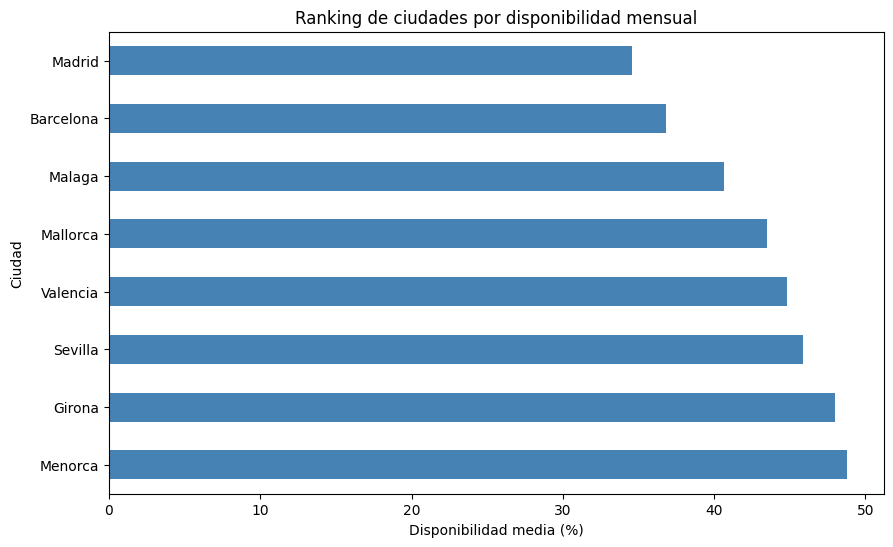

In [7]:
disponibilidad_mensual = (
    df_operaciones
    .groupby("city")["avail_ratio_30"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10,6))

disponibilidad_mensual.plot(
    kind="barh",
    color="steelblue"
)

ax.set_xlabel("Disponibilidad media (%)")
ax.set_ylabel("Ciudad")
ax.set_title("Ranking de ciudades por disponibilidad mensual")

plt.show()

In [8]:
periodos = {
    "30d": ("availability_30", 30),
    "60d": ("availability_60", 60),
    "90d": ("availability_90", 90),
    "365d": ("availability_365", 365)
}
kpi_operaciones = {
    "anuncios_totales": int(total_anuncios)
}

for p, (col, dias) in periodos.items():
    
    disponibles = (df_operaciones[col] > 0).sum()
    
    ocupacion = ((dias - df_operaciones[col]) / dias).mean() * 100
    
    kpi_operaciones[f"disponibles_{p}"] = int(disponibles)
    kpi_operaciones[f"ocupacion_{p}_%"] = round(ocupacion,1)

kpi_operaciones_df = pd.DataFrame(
    list(kpi_operaciones.items()),
    columns=["KPI", "Valor"]
)

kpi_operaciones_df

,KPI,Valor
0,anuncios_totales,6615.0
1,disponibles_30d,4661.0
2,ocupacion_30d_%,59.5
3,disponibles_60d,5057.0
4,ocupacion_60d_%,54.7
5,disponibles_90d,5288.0
6,ocupacion_90d_%,51.1
7,disponibles_365d,5747.0
8,ocupacion_365d_%,48.9


## Resultados / archivos generados

Conclusiones: La disponibilidad de alojamientos aumenta conforme el horizonte temporal es mayor, lo que refleja un comportamiento esperado en mercados turísticos donde las reservas se concentran en el corto plazo. Madrid y Barcelona presentan los niveles más bajos de disponibilidad mensual, lo que sugiere una mayor presión de demanda. En contraste, ciudades como Girona y Menorca muestran mayores niveles de disponibilidad relativa, lo que podría indicar menor demanda o mayor oferta de alojamientos.

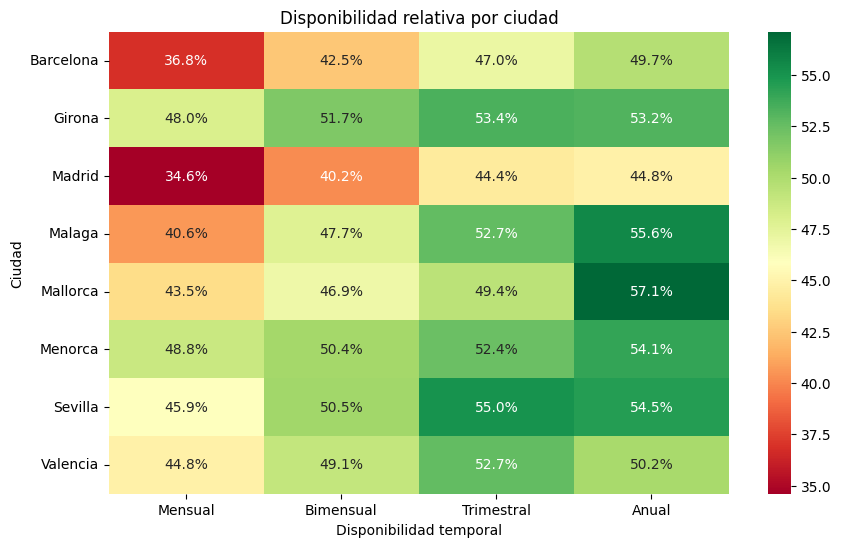

Gráfico guardado en: c:\Users\Usuario\ProjecteData\Equip_25\Data\figures\operaciones_heatmap_disponibilidad.png


In [9]:
data = disponibilidad_ciudad_pct.set_index("city")
labels = data.round(2).astype(str) + "%"

fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap(
    data,
    annot=labels,
    cmap="RdYlGn",
    fmt=""
)

ax.set_title("Disponibilidad relativa por ciudad")
ax.set_ylabel("Ciudad")
ax.set_xlabel("Disponibilidad temporal")
ax.set_xticklabels(["Mensual","Bimensual","Trimestral","Anual"])

plt.show()
guardar_grafico(fig,"operaciones_heatmap_disponibilidad")

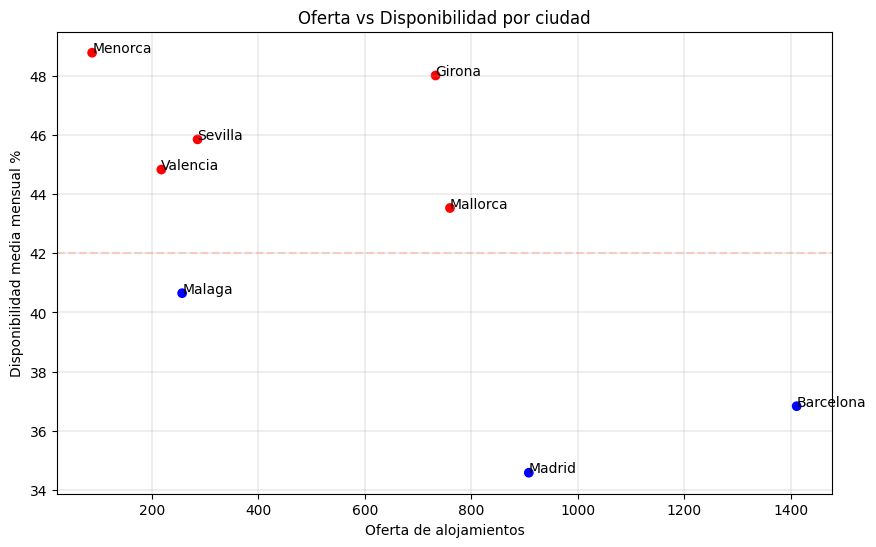

Gráfico guardado en: c:\Users\Usuario\ProjecteData\Equip_25\Data\figures\operaciones_scatter_oferta_disponibilidad.png


In [10]:
fig, ax = plt.subplots(figsize=(10,6))
colors = [
    "red" if x > 42 else "blue"
    for x in df_ciudad_oferta["disponibilidad_media"]
]

ax.scatter(
    df_ciudad_oferta["oferta_disponible"],
    df_ciudad_oferta["disponibilidad_media"],
    c=colors
)

for i, row in df_ciudad_oferta.iterrows():
    ax.text(
        row["oferta_disponible"],
        row["disponibilidad_media"],
        row["city"]
    )

ax.set_xlabel("Oferta de alojamientos")
ax.set_ylabel("Disponibilidad media mensual %")
ax.set_title("Oferta vs Disponibilidad por ciudad")
ax.axhline(42, color="coral", linestyle="--", alpha=0.3)
ax.grid(True, linewidth=0.3)

plt.show()
guardar_grafico(fig,"operaciones_scatter_oferta_disponibilidad")